In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
BH_dir = os.listdir('./results')
BH_dir.sort()
BH_dir

['M1e+12', 'M1e+13', 'M1e+14', 'M1e+15']

In [9]:
PBH_spectra = {}
for BH in BH_dir:
    parent_dir = os.path.join('./results', BH)
    sec_path = f'{parent_dir}/instantaneous_secondary_spectra.txt'
    pri_path = f'{parent_dir}/instantaneous_primary_spectra.txt'

    df_sec = pd.read_csv(sec_path, sep='\s+', skiprows=1)

    PBH_spectra[BH] = df_sec

In [10]:
df_sec = pd.read_csv(sec_path, sep='\s+', skiprows=1)
df_pri = pd.read_csv(pri_path, sep='\s+', skiprows=1)

In [ ]:
PBH_spectra['M1e+14'].columns.to_list()

['energy/particle',
 'photon',
 'electron',
 'muon',
 'nu_e',
 'nu_mu',
 'nu_tau',
 'pipm',
 'K0L',
 'Kpm',
 'proton',
 'neutron']

In [ ]:
PBH_spectra['M1e+14']['energy/particle']

0          0.000001
1          0.000001
2          0.000002
3          0.000002
4          0.000003
          ...      
95     35938.100000
96     46415.900000
97     59948.400000
98     77426.400000
99    100000.000000
Name: energy/particle, Length: 100, dtype: float64

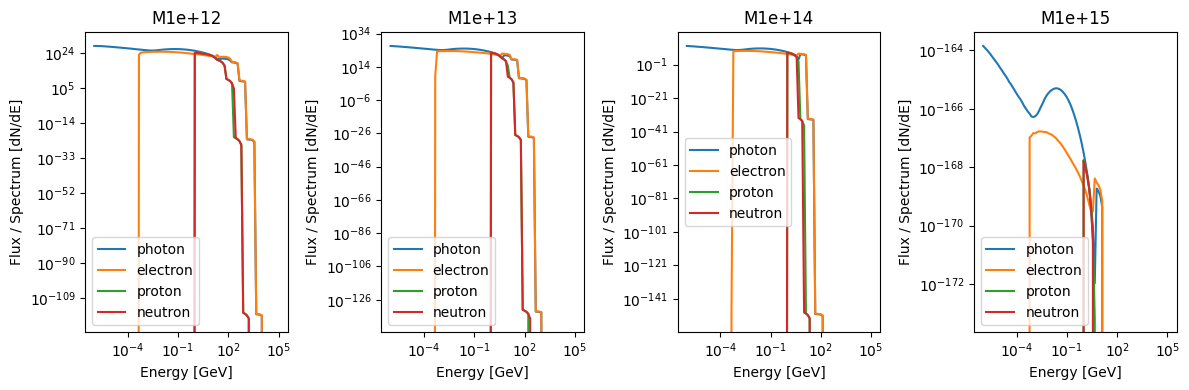

In [ ]:
# 1. Define the species you want to plot (all columns except the energy index)
#species = df_sec.columns.to_list()[1:]
species = ['photon', 'electron', 'proton', 'neutron']

fig, ax = plt.subplots(1, len(BH_dir), figsize=(12, 4))
# 2. Loop through each species and plot it against energy
for i, BH in enumerate(BH_dir):
    for s in species:
        ax[i].plot(PBH_spectra[BH]['energy/particle'], PBH_spectra[BH][s], label=s, linewidth=1.5)

    # 3. Formatting for Astrophysics Spectra
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')

    ax[i].set_xlabel('Energy [GeV]')
    ax[i].set_ylabel('Flux / Spectrum [dN/dE]')
    ax[i].set_title(BH)

    # Put the legend outside if it's too crowded
    ax[i].legend()
    #plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

GEV_TO_ERG = 1e9 * 1.6e-19 * 1e7

# -----------------------------
def luminosity():

    df = PBH_spectra['M1e+13']

    # Convert energy grid from GeV → erg
    E = df['energy/particle'].values * GEV_TO_ERG

    species_list = ["photon", "electron", "proton", "neutron"]

    total_dε_dr = 0.0

    for sp in species_list:
        # Convert dN/dE from GeV^-1 → erg^-1
        dN_dE = df[sp].values / GEV_TO_ERG

        # Integrate over energy
        dε_dr = np.trapz(dN_dE, E)

        print(sp, dε_dr)
        total_dε_dr += dε_dr

    return total_dε_dr

luminosity()

photon 1.444636480250582e+24
electron 8.882600065948277e+22
proton 2.413479264777322e+22
neutron 2.2086873807590783e+22


1.5796841473654292e+24

In [ ]:
"""
CGS Unit is used.
"""

import numpy as np

# General Constant
me = 9.1093837e-31 * 1000 # g
mp = 1.67262192e-27 * 1000 # g
c = 299792458 * 100 # cm/s
G = 6.67430e-8 # cgs
statC_e = 4.803e-10
#E_e = me * (c ** 2) / C_e # m_e c^2 in eV
r_e =  2.8179403205e-15 * 100 # electron radius in cm
r_p = 0.877e-15 * 100 # proton radius in cm
proton_energy = 0.00160218  # erg
M_SOLAR = 1.98e33 # g
L_SOLAR = 3.828e33 # erg/s
h = 6.626e-27 # planck constant in cgs
hbar = h / (2 * np.pi)
mH = 1.6735e-24 # mass of hydrogen in g
kB = 1.38e-16 # boltzmann constant in cgs
sigma = 5.67e-5 # stefann constant
a = 4 * sigma / (3 * c)
hbar * c**6 / (15360 * np.pi * G**2 * (1e11**2))

3.5615844379948646e+23